# Ejercicio Práctico 2: Valuación de opciones exóticas con Monte Carlo

Valuar opciones europeas y exóticas usando simulación Monte Carlo. Comparar cómo cambia el precio cuando el payoff depende de la trayectoria completa del activo o incluye restricciones adicionales como barreras.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibilidad
np.random.seed(42)


# Parámetros del activo

S0    = 738.85      # Precio actual de SPY
K     = 740         # Strike ATM cercano al precio actual
T     = 30/365      # 30 días al vencimiento
sigma = 0.18        # Volatilidad anual aproximada
r     = 0.04        # Tasa libre de riesgo anual

# Barrera para up-and-out
B = 780

# Simulación
M = 50_000          # Número de trayectorias
N = 252             # Pasos de tiempo

dt = T / N

print(f"Precio inicial S0 : ${S0}")
print(f"Strike K          : ${K}")
print(f"Volatilidad σ     : {sigma}")
print(f"Tasa libre r      : {r}")
print(f"Barrera B         : ${B}")
print(f"Trayectorias MC   : {M}")

Precio inicial S0 : $738.85
Strike K          : $740
Volatilidad σ     : 0.18
Tasa libre r      : 0.04
Barrera B         : $780
Trayectorias MC   : 50000


## Definición de parámetros

Se utilizará SPY como activo subyacente debido a su alta liquidez y uso frecuente en el mercado de opciones.

Los parámetros elegidos son:

- \( S_0 = 738.85 \): precio actual aproximado de SPY.
- \( K = 740 \): strike cercano al precio spot, opción at-the-money.
- \( T = 30/365 \): vencimiento de 30 días.
- \( \sigma = 0.18 \): volatilidad anual aproximada de SPY.
- \( r = 0.04 \): tasa libre de riesgo anual.
- \( B = 780 \): barrera para la opción up-and-out.

La barrera se colocó por encima del precio actual para que exista una probabilidad razonable de cancelación, pero sin que la opción pierda valor inmediatamente.

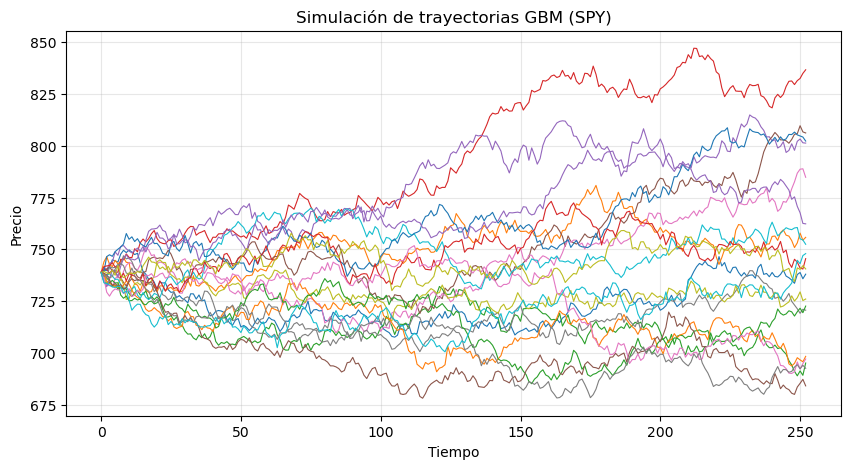

In [2]:
# Simulación de trayectorias GBM completas

def simular_gbm(S0, r, sigma, T, N, M):
    """
    Simula trayectorias completas de un GBM
    """
    dt = T / N

    # Incrementos brownianos
    Z = np.random.randn(M, N)

    # Trayectorias log
    S = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * sigma**2) * dt +
            sigma * np.sqrt(dt) * Z[:, t-1]
        )

    return S


# Generar trayectorias
paths = simular_gbm(S0, r, sigma, T, N, M)

# Visualización de algunas trayectorias
plt.figure(figsize=(10,5))
for i in range(20):
    plt.plot(paths[i], linewidth=0.8)

plt.title("Simulación de trayectorias GBM (SPY)")
plt.xlabel("Tiempo")
plt.ylabel("Precio")
plt.grid(alpha=0.3)
plt.show()

In [3]:

# PAYOFFS MONTE CARLO


# Precio final
ST = paths[:, -1]

# 1. Call europea (referencia)
payoff_call = np.maximum(ST - K, 0)

# 2. Put europea (referencia)
payoff_put = np.maximum(K - ST, 0)

# 3. Opción asiática call (promedio)
S_prom = paths.mean(axis=1)
payoff_asian = np.maximum(S_prom - K, 0)

# 4. Up-and-out call (barrera)
# Se anula si en algún momento supera B
knocked_out = (paths.max(axis=1) >= B)
payoff_barrier = np.where(knocked_out, 0, np.maximum(ST - K, 0))


# Descuento a valor presente
discount = np.exp(-r * T)

precio_call = discount * np.mean(payoff_call)
precio_put = discount * np.mean(payoff_put)
precio_asian = discount * np.mean(payoff_asian)
precio_barrier = discount * np.mean(payoff_barrier)

print("=== PRECIOS MONTE CARLO ===\n")
print(f"Call europea      : ${precio_call:.4f}")
print(f"Put europea       : ${precio_put:.4f}")
print(f"Call asiática     : ${precio_asian:.4f}")
print(f"Call up-and-out   : ${precio_barrier:.4f}")

=== PRECIOS MONTE CARLO ===

Call europea      : $15.6670
Put europea       : $14.5156
Call asiática     : $8.7155
Call up-and-out   : $3.4154


In [4]:
# TABLA COMPARATIVA

resultados = pd.DataFrame({
    "Opción": ["Call europea", "Put europea", "Call asiática", "Call up-and-out"],
    "Precio MC": [precio_call, precio_put, precio_asian, precio_barrier]
})

resultados

,Opción,Precio MC
0,Call europea,15.666976
1,Put europea,14.515625
2,Call asiática,8.715549
3,Call up-and-out,3.415439


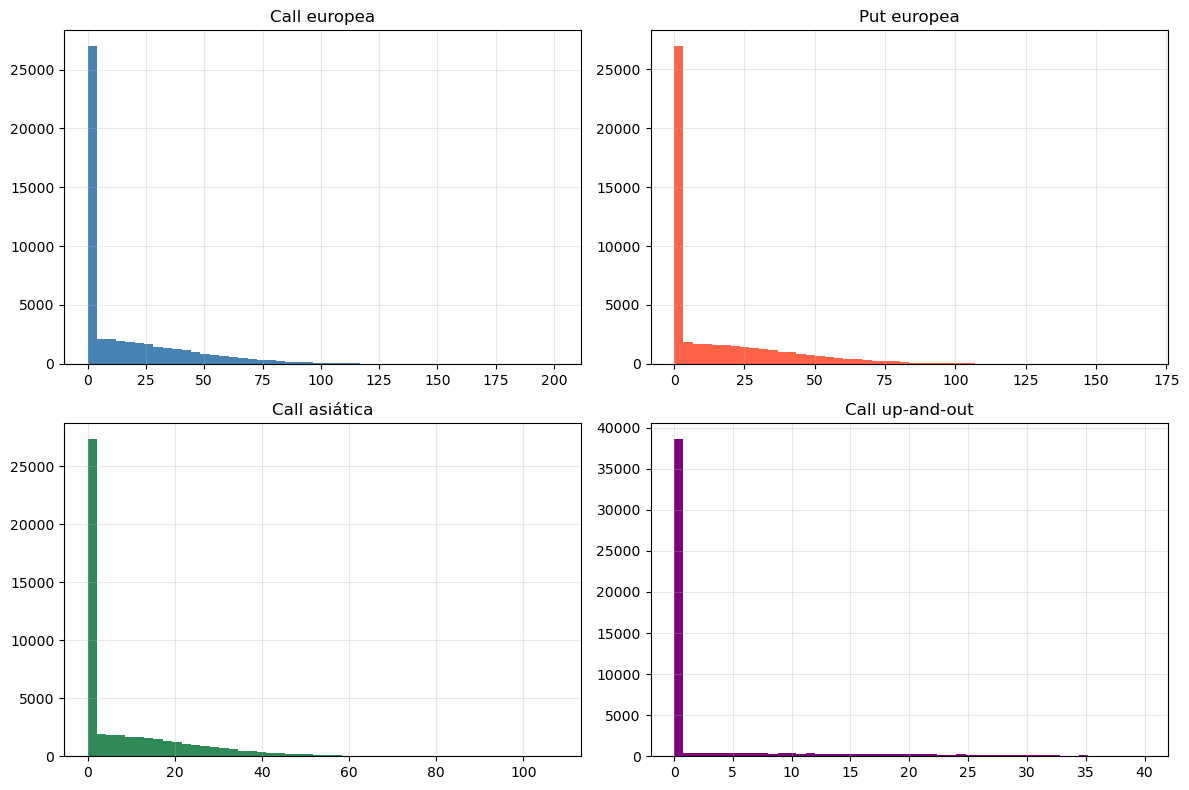

In [5]:

# DISTRIBUCIÓN DE PAYOFFS

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].hist(payoff_call, bins=50, color='steelblue')
axs[0, 0].set_title("Call europea")

axs[0, 1].hist(payoff_put, bins=50, color='tomato')
axs[0, 1].set_title("Put europea")

axs[1, 0].hist(payoff_asian, bins=50, color='seagreen')
axs[1, 0].set_title("Call asiática")

axs[1, 1].hist(payoff_barrier, bins=50, color='purple')
axs[1, 1].set_title("Call up-and-out")

for ax in axs.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretación 

Las diferencias en los precios de las opciones se explican por la estructura del payoff y la información que cada contrato utiliza.

### Call europea
Depende únicamente del precio final S_T, por lo que incorpora toda la volatilidad del activo. Esto genera mayor incertidumbre en el payoff y, por lo tanto, un precio más alto.



### Put europea
También depende solo del precio final, pero en sentido inverso. Sirve como referencia base del modelo.



### Opción asiática
Su payoff depende del promedio del precio durante toda la trayectoria.  
Esto reduce el impacto de movimientos extremos porque el promedio suaviza la volatilidad.

Menor variabilidad del payoff - menor valor esperado - menor precio.



### Up-and-out call
Incluye una restricción adicional: si el precio supera la barrera \(B\), la opción se cancela.

Esto reduce significativamente los escenarios donde la opción puede terminar ITM.

Más restricciones en el payoff - menor probabilidad de pago - precio más bajo.



## Conclusión

El orden de precios obtenido:

Call europea > Put europea > Call asiática > Up-and-out


refleja directamente el nivel de restricciones del payoff:

- Sin restricciones - más cara  
- Promedio - reduce volatilidad - más barata  
- Barrera - elimina escenarios - la más barata